In [ ]:
import pandas as pd
df = pd.read_csv("confirmed_global.csv")
df = df.drop(columns=["Province/State", "Lat", "Long"], errors='ignore')
df = df[df["Country/Region"] == "India"]
df = df.drop(columns=["Country/Region"])
df = df.melt(var_name="Date", value_name="Admissions")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df['Admissions'] = df['Admissions'].diff().fillna(0)
df['Admissions'] = df['Admissions'] / 1000
df.to_csv("hospital_admissions.csv", index=False)

print("✅ Dataset ready: hospital_admissions.csv")
print(df.head())

✅ Dataset ready: hospital_admissions.csv
        Date  Admissions
0 2020-01-22         0.0
1 2020-01-23         0.0
2 2020-01-24         0.0
3 2020-01-25         0.0
4 2020-01-26         0.0


/tmp/ipykernel_6435/2306012172.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [ ]:
df = pd.read_csv("/content/hospital_admissions.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
print(df.head())

            Admissions
Date                  
2020-01-22         0.0
2020-01-23         0.0
2020-01-24         0.0
2020-01-25         0.0
2020-01-26         0.0


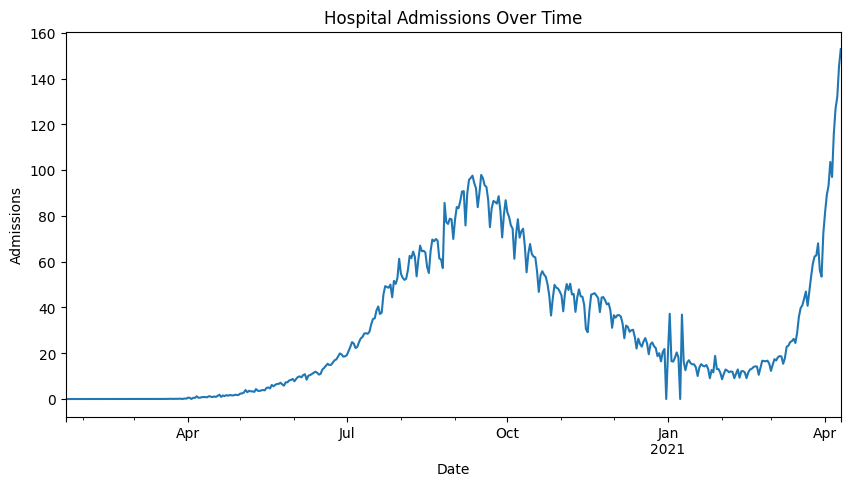

In [ ]:
import matplotlib.pyplot as plt
df['Admissions'].plot(figsize=(10,5))
plt.title("Hospital Admissions Over Time")
plt.xlabel("Date")
plt.ylabel("Admissions")
plt.show()

In [ ]:
print("\n--- Hospital Admission Forecasting Input ---")
days = int(input("Enter number of future days to predict: "))
print("\nSelect ARIMA parameters (model tuning):")
p = int(input("Enter AR (p) value (0-5): "))
d = int(input("Enter differencing (d) value (0-2): "))
q = int(input("Enter MA (q) value (0-5): "))
threshold = int(input("\nEnter hospital capacity threshold: "))


--- Hospital Admission Forecasting Input ---
Enter number of future days to predict: 3

Select ARIMA parameters (model tuning):
Enter AR (p) value (0-5): 2
Enter differencing (d) value (0-2): 1
Enter MA (q) value (0-5): 2

Enter hospital capacity threshold: 100000


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(df['Admissions'], order=(p,d,q))
model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Admissions   No. Observations:                  445
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1304.014
Date:                Wed, 01 Apr 2026   AIC                           2618.027
Time:                        03:53:25   BIC                           2638.506
Sample:                    01-22-2020   HQIC                          2626.103
                         - 04-10-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4419      0.011    -40.591      0.000      -0.463      -0.421
ar.L2         -0.9890      0.009   -107.473      0.000      -1.007      -0.971
ma.L1          0.4095      0.024     16.781      0.0

In [ ]:
forecast = model_fit.forecast(steps=days)

print("\n📈 Forecasted Admissions:")
print(forecast)

print("\n📊 Average Forecast:", forecast.mean())


📈 Forecasted Admissions:
2021-04-11    152.843413
2021-04-12    149.854136
2021-04-13    151.210300
Freq: D, Name: predicted_mean, dtype: float64

📊 Average Forecast: 151.30261637326578


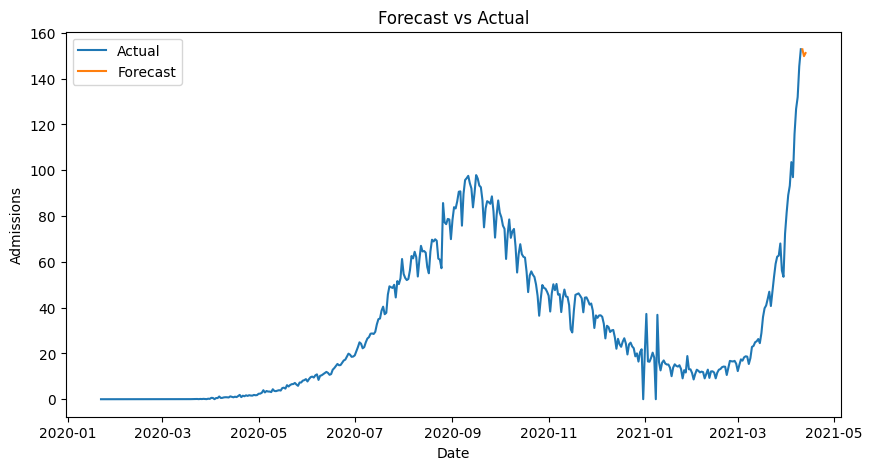

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Admissions'], label="Actual")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.title("Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Admissions")
plt.show()

In [ ]:
if forecast.mean() > threshold:
    print("⚠ Expected admissions exceed hospital capacity!")
else:
    print("✅ Admissions are within manageable hospital capacity")

✅ Admissions are within manageable hospital capacity
